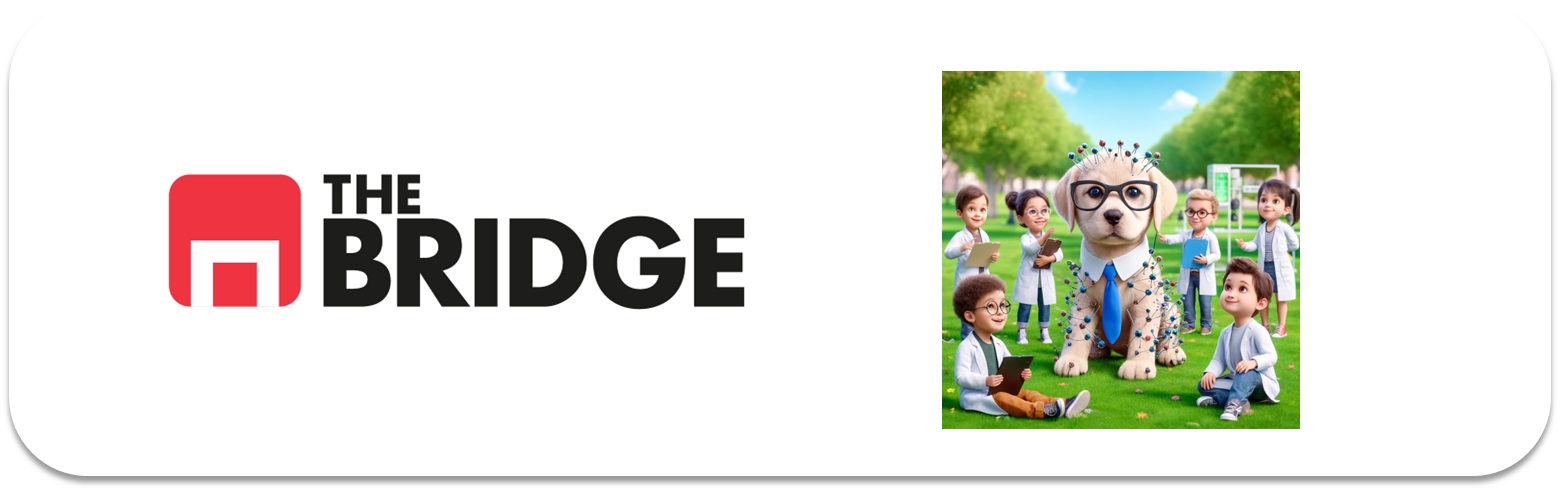

Puedes utilizar estos entornos para ejecutar el código (si lo haces así, tienes que subir los datos)

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ds-online-tb/DS-Online/blob/main/05_Deep_Learning/Sprint_16/Unidad_03_RNN_Redes_Recurrentes/01_Workout/03_Series_Temporales_con_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ds-online-tb/DS-Online/blob/main/05_Deep_Learning/Sprint_16/Unidad_03_RNN_Redes_Recurrentes/01_Workout/03_Series_Temporales_con_RNN.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

## REDES RECURRENTES (aplicado a series temporales)

Adaptado de [Hands on Machine Learning for Python](https://learning.oreilly.com/library/view/hands-on-machine-learning/9781492032632/ch15.html#cnn_chapter), utilizando lo aprendido en las sesiones de series temporales

Requisitos y recomendaciones:  
* Python 3.7 o superior
* Tensorflow 2.8 o superior
* Es preferible utilizar un entorno con GPU (si se quiere probar la parte LSTM y GRU mejor con Nvida, ya que Keras emplea cuRNN que es una mejora basada en CUDA para Nvidia), por ejemplo Colab de Google

In [ ]:
import numpy as np
import pandas as pd
import sys
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from pmdarima.arima import ARIMA, auto_arima
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from packaging import version
assert version.parse(tf.__version__) >= version.parse("2.8.0")

pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

Algunas preconfiguraciones para hacer más "visibles" los gráficos

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### El problema: Predecir el uso del transporte público en Chicago

Como ya hicimos al ver las series temporales con modelos tradicionales, vamos a utilizar los datos diarios de utilización de autobuses y tren de la ciudad de Chicago. Te recuerdo que están extraídos de su portal de datos públicos, y te recomiendo que te des una vuelta por él. Chicago es una de las ciudades más Smart del mundo y llevan recogiendo datos de diversos temas desde hace mucho tiempo... [Chicago's Data Portal](https://data.cityofchicago.org/)


Cargemos y preparemos los datos. Recuerda en series temporales conviene convertir a datatime las fechas y usarlas como índices.

In [ ]:
import pandas as pd                                   # Importamos la librería pandas para trabajar con datos 
DATA_PATH = "./data/CTA - Ridership - Daily Boarding Totals.csv"  # Ruta del archivo CSV 
df = pd.read_csv(DATA_PATH, parse_dates=["service_date"])  # Leemos el CSV y convertimos 'service_date' a fecha 
df.columns = ["date", "day_type", "bus", "rail", "total"]  # Renombramos las columnas para mayor claridad 
df["date"] = pd.to_datetime(df["date"])                   # Aseguramos que la columna 'date' es tipo datetime 
df = df.sort_values("date").set_index("date")             # Ordenamos por fecha y la usamos como índice 
# Hacemos un poco de limpieza
df = df.drop("total", axis=1)                             # Eliminamos 'total' (es redundante: bus + rail) 
df = df.drop_duplicates()                                 # Eliminamos filas duplicadas

Como en cualquier otro dataset echamos un vistazo, pero además siendo una serie recuerda que es importante descomponerla y analizar su estacionariedad.

In [ ]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


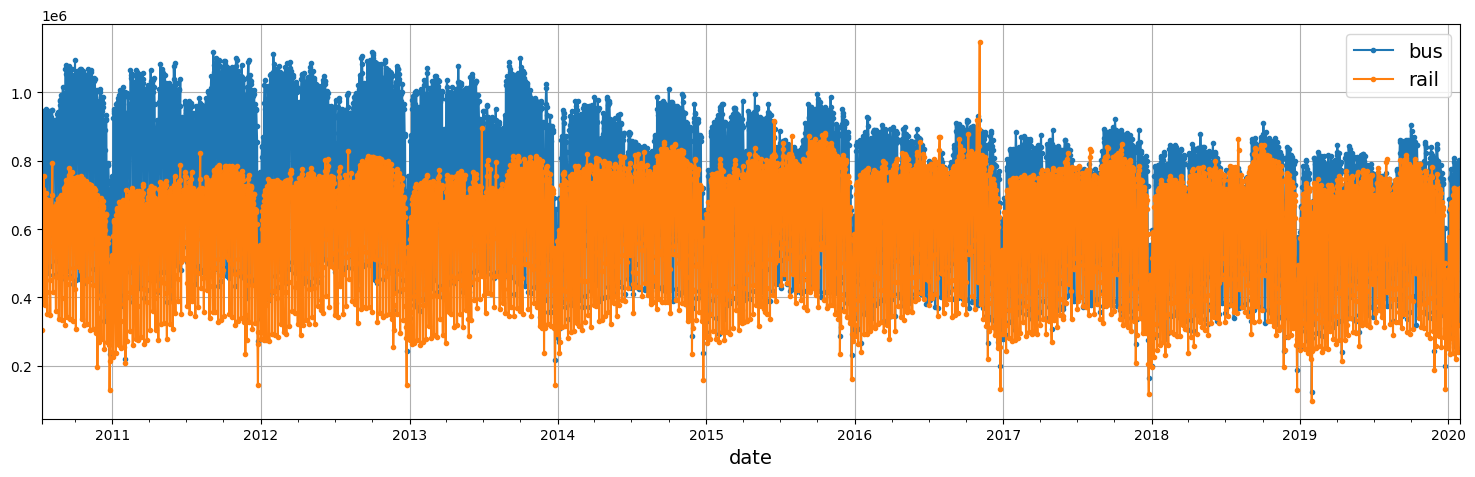

In [ ]:
df["2010-07-11":"2020-01-31"].plot(grid = True, marker = ".", figsize = (15,5) ) # Al hacer la fecha el indice podemos utilizarla facilmente como índice
plt.tight_layout()

Como recordarás de la unidad de series temporales... ok, vale, no lo recuerdas, pero te lo recuerdo yo... estas series tenían tendencia y dos tipos de estacionalidad (semanal y anual)

Para ver la estacionalidad semanal, pintábamos la serie y su desplazada una semana:

<Axes: xlabel='date'>

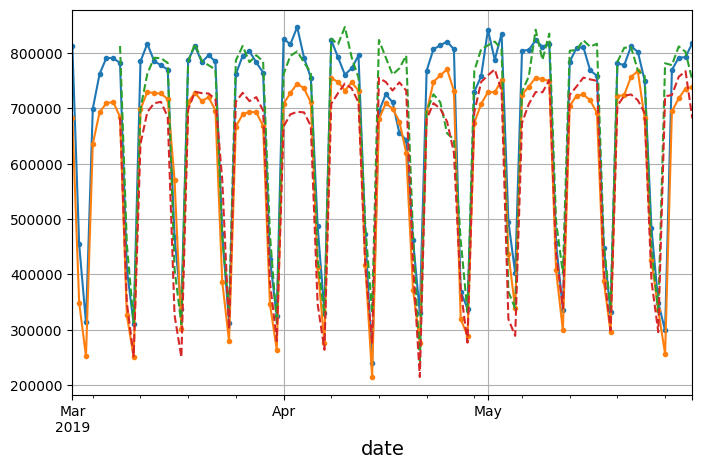

In [ ]:
comienzo = "2019-03"
fin = "2019-05"

fig, axs = plt.subplots(1, 1, figsize=(8, 5))
df[comienzo:fin].plot(ax=axs, legend=False, marker=".")  # original time series
df[comienzo:fin].shift(7).plot(ax=axs, grid=True, legend=False, linestyle="--")  # lagged

Se ve claramente como se superponen casi perfectamente, lo que además nos invitaba a generar un modelo "naive" como baseline. Pero en este caso haremos uso de un modelo SARIMA como baseline. Antes descompogamos la serie mensualizandola (calculando medias por meses) para ver la estacionalidad anual:

(Recordemos que podíamos hacer descomposicion multiplicativa o aditiva)

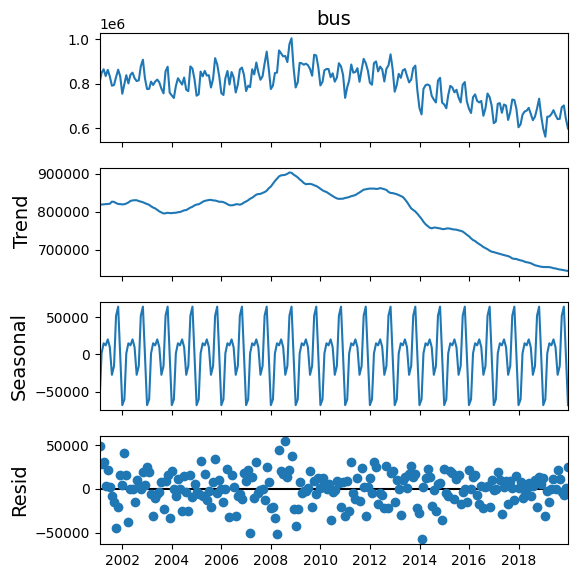

In [ ]:
df_mensualizada = df.resample("M").mean(numeric_only= True)
result_add = seasonal_decompose(df_mensualizada["bus"][:"2019-12-31"], model = 'additive', extrapolate_trend = 'freq')

# Plot
plt.rcParams.update({'figure.figsize': (6,6)})
result_add.plot();

Se puede observar la repetición del patrón anual. 

Además también existe una tendencia clara. En definitiva no son series estacionarias, aunque por teminar de recordar vamos a hacer el test de Dickey-Fuller aumentado o ADF test:

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['bus'].values)
result[1]

np.float64(0.11251437221393884)

El p-value es mayor de 0.05 así que no podemos rechazar la hipótesis nula de no estacionariedad (como ya esperábamos)

En definitiva, si estuvieramos intentando crear un modelo predictivo de la serie temporal, utilizaríamos un SARIMA con diferenciación (d distinto de 0) y con estacionalidad.

De hecho, empleemos como baseline el SARIMA que vimos en la unidad de series temporales, primero prediciendo a 14 días vista:

In [ ]:
origin, today = "2019-01-01", "2019-05-31"
#origin,today = "2018-01-01", "2018-12-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
rail_series_valid = df.loc["2019-06":"2019-06"]["rail"].asfreq("D")

model = ARIMA(order=(1,0, 1),
        seasonal_order=(0, 1, 1, 7)) # Orden: P,D,Q,s -> s= 7 porque recuerda que era el periodo semanal tan pronunciado
model = model.fit(rail_series)
y_pred = model.predict(1)  # returns 427,758.6

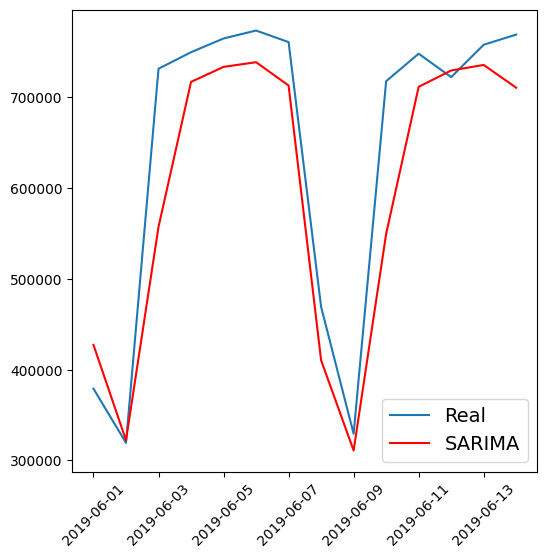

In [ ]:
y_valid = rail_series_valid.iloc[:14]
y_pred = model.predict(14) # dos semanas
plt.plot(y_valid, label = "Real")
plt.plot(y_pred,color='red', label = "SARIMA")
plt.xticks(rotation = 45)
plt.legend()

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("MAPE:", mean_absolute_percentage_error(y_valid, y_pred) * 100)

RMSE: 73503.55866330178
MAPE: 8.195451820649879


Muy bien ahí tenemos nuestro baseline, ahora veamos que tal lo hacemos usando redes neuronales

***

### Con MLPs o Redes densas (DNN, deep neural networks)

Las redes recurrentes además de su complejidad para "visualizarlas" mentalmente y la propia de tener que configurarlas como cualquier otra capa de DL, añaden la farragosa tarea de preparar los dataset de entrada... Tal como vimos al hablar de entrenamiento en las sesiones teóricas.

Entre otras cosas porque ahora la red espera batches de secuencias con multiples posibilidades en los targets... 


Por ejemplo, si tuvieramos una serie temporal de ingresos de una empresa con valores diarios tal como:

[12500, 3500, 1234, 111000, 2345, 8889, 12567]

Y quisieramos predecir el día siguiente con los tres días anteriores tendríamos que construir el siguiente dataset:

[12500,3500,1234], target: [111000]  
[3500,1234,111000], target: [2345]  
[1234,111000,2345], target: [8889]  
[111000,2345,8889], target: [12567]  

Donde ahora cada fila es una instancia y una secuencia con su target

Para poder preparar los batches y el dataset de entrenamiento a partir del dataframe con los datos, Keras nos da ciertas "facilidades"

In [ ]:
# Al igual que teniamos el "generador" de imágenes sintéticas, tensorflow tiene un generador de datasets para series temporales que nos viene perfecto (https://keras.io/api/preprocessing/timeseries/)
# Serie temporal simple (nuestros datos)
my_series = [0, 1, 2, 3, 4, 5]

# Creamos dataset para modelos de series temporales
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    
    my_series,                # datos originales (input base)
    
    targets=my_series[3:],    # lo que queremos predecir (target) - # the targets are 3 steps into the future
                                 # empieza en índice 3 → estamos prediciendo 3 pasos adelante
    
    sequence_length=3,        # tamaño de cada ventana (cuántos valores usa el modelo como input)
    
    batch_size=2,             # cuántas secuencias agrupamos por lote
    
    shuffle=False             # NO mezclar → importante en series temporales (orden importa)- # Este parametro permite controlar que mezclemos las secuencias (como en el ejemplo del surf en las sesiones teóricas)
)

# Convertimos a lista para ver el resultado
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

En este paso se transforma una serie temporal en un conjunto de ejemplos supervisados para entrenamiento. A partir de la serie original, se crean ventanas deslizantes de longitud 3, donde cada secuencia de entrada contiene tres valores consecutivos y el target es el valor siguiente.

La función timeseries_dataset_from_array automatiza este proceso y además agrupa las secuencias en batches. En este ejemplo, el modelo aprende a predecir el siguiente valor de la serie a partir de los tres anteriores, manteniendo el orden temporal gracias a shuffle=False.  
PROBLEMAS AUTOSUPERVISADO  

La salida dice algo parecido a:

[(<tf.Tensor: shape=(2, 3) ... array([[0,1,2],[1,2,3]])>,  
  <tf.Tensor: shape=(2,) ... array([3,4])>),  

 (<tf.Tensor: shape=(1, 3) ... array([[2,3,4]])>,  
  <tf.Tensor: shape=(1,) ... array([5])>)]  

Eso significa:  

Primer batch  
shape=(2,3) → 2 secuencias, cada una con 3 valores  
shape=(2,) → 2 targets   
Segundo batch  
shape=(1,3) → 1 secuencia de 3 valores  
shape=(1,) → 1 target  

Ha creado dos batches, el primero con las dos posibles primeras secuencias posibles de 3 intervalos [0,1,2] y [1,2,3] y el segundo con una sóla secuencia porque no tiene más datos para generarla: [2,3,4]

In [ ]:
# Serie temporal realista (ejemplo de ingresos)
my_series = [12500, 3500, 1234, 111000, 2345, 8889, 12567]

# Creamos dataset para modelos de series temporales
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    
    my_series,                    # datos originales (serie completa)
    
    targets=my_series[3:],        # targets → empezamos en índice 3 - # the targets are 3 steps into the future
                                 # esto hace que cada secuencia prediga el siguiente valor
    
    sequence_length=3,            # cada input tendrá 3 valores (ventana temporal)
    
    batch_size=2,                 # agrupamos las secuencias en lotes de 2
    
    shuffle=True                  # mezcla las secuencias (NO recomendado normalmente en series temporales)- # Este parametro permite controlar que mezclemos las secuencias (como en el ejemplo del surf en las sesiones teóricas)
)

# Convertimos a lista para ver cómo queda el dataset
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[111000,   2345,   8889],
         [ 12500,   3500,   1234]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 12567, 111000], dtype=int32)>),
 (<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[  3500,   1234, 111000],
         [  1234, 111000,   2345]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([2345, 8889], dtype=int32)>)]

[(Tensor(shape=(2,3)), Tensor(shape=(2))),  
 (Tensor(shape=(2,3)), Tensor(shape=(2)))]    

🧩 Batch 1 (ejemplo)  
X = [ [3500, 1234, 111000],  
 [12500, 3500, 1234]]  

y = [2345, 111000]  

👉 Interpretación:  

Primera fila:    
[3500,1234,111000] → 2345    
Segunda fila:  
[12500,3500,1234] → 111000  

🧩 Batch 2  
X = [ [1234, 111000, 2345],  
 [111000, 2345, 8889]]  

y = [8889, 12567]  
🧠 ¿Por qué salen en ese orden raro?   
👉 Por esto:  
shuffle=True    
✔️ Mezcla las secuencias  
✔️ No respeta el orden temporal   
AUMENTAR LA ROBUSTES del modelo 

Hacemos tres datasets: entrenamiento, validación y test y aplicamos "normalización" casera, aunque al ser una serie univariante (sólo vamos a usar por ahora una única característica) no debería afectarle

In [ ]:
df["rail"].max()

np.int64(1146516)

In [ ]:
df["bus"].max()

np.int64(1211992)

In [ ]:
# Necesario escalar entre 1.000.000
rail_train = df["rail"]["2016-01":"2019-05"] / 1e6  
# Cogemos la columna "rail" del dataframe
# Seleccionamos desde enero 2016 hasta mayo 2019 → datos de entrenamiento
# Dividimos entre 1e6 (1.000.000) → para escalar los valores (hacerlos más pequeños)

rail_valid = df["rail"]["2019-04-06":"2019-06"] / 1e6  # Para usar Junio como validación tenemos que empezar 56 días antes
# Datos de validación (junio)
# Empieza antes (abril) → para tener contexto temporal (ventanas previas)
# IMPORTANTE en series temporales: necesitas datos anteriores para crear secuencias

rail_test = df["rail"]["2019-07":] / 1e6  
# Datos de test → desde julio en adelante
# Aquí evaluas el modelo final (datos no vistos)

En este paso se divide la serie temporal en conjuntos de entrenamiento, validación y test respetando el orden temporal de los datos. A diferencia de los problemas clásicos de machine learning, en series temporales no se deben mezclar los datos, ya que el orden es fundamental.

El conjunto de validación comienza antes del periodo objetivo para asegurar que el modelo dispone del contexto necesario al construir las secuencias (ventanas temporales). Además, los valores se escalan dividiéndolos por 1e6 para facilitar el entrenamiento del modelo.

De los dataframes pasamos a los datasets preparados para entrenar las capas recurrentes usando el comentado timeseries_dataset_from_array y construyendo el dataset de entrada para una predicción al día siguiente después de 56 días (es decir 8 semanas) (esta es una selección arbitraría y podríamos haber empleado otro criterio, pero son más o menos dos meses).

In [ ]:
seq_length = 56  
# longitud de la ventana → el modelo usa 56 días para predecir el siguiente

tf.random.set_seed(42)  # extra code – ensures reproducibility
# fija la semilla → resultados reproducibles (muy importante en DL)

# =========================
# 📊 DATASET DE ENTRENAMIENTO
# =========================
train_ds = tf.keras.utils.timeseries_dataset_from_array(

    rail_train.to_numpy(),                # convertimos la serie a array (TensorFlow lo necesita)
    
    targets=rail_train[seq_length:],      # targets → desplazamos 56 posiciones
                                         # cada secuencia predice el día 57
    
    sequence_length=seq_length,           # cada input tiene 56 valores (días)
    
    batch_size=32,                       # el modelo entrena en grupos de 32 secuencias
    
    shuffle=True,                        # mezclamos las secuencias (importante para entrenamiento)
    
    seed=42                              # semilla para reproducibilidad del shuffle
)

 # Creará batches de 32 secuencias formadas por 56 días seguidos y target el 57 y a su vez esas secuencias estarán desordenadas (no son 56 días y luego los 56 días desplazados una vez...)
# 👉 Resultado:
# batches de 32 secuencias
# cada secuencia = 56 días
# target = día siguiente (día 57)
# PERO las secuencias están mezcladas (no en orden temporal)


# =========================
# 📊 DATASET DE VALIDACIÓN
# =========================
valid_ds = tf.keras.utils.timeseries_dataset_from_array(

    rail_valid.to_numpy(),               # datos de validación
    
    targets=rail_valid[seq_length:],     # targets desplazados 56 posiciones
    
    sequence_length=seq_length,          # ventanas de 56 días
    
    batch_size=32                        # batches de 32
)
# En cambio la validación son secuencias consecutivas (es decir los 56 primeros días de 2019 y predigo el 57, los días 1 a 57 y target el 58, etc)

# 👉 IMPORTANTE:
# aquí NO hay shuffle → las secuencias están en orden temporal

Se construyen datasets de entrenamiento y validación a partir de la serie temporal utilizando ventanas deslizantes de longitud 56. Cada secuencia de entrada contiene los valores de los 56 días anteriores y el target corresponde al día siguiente.

En el conjunto de entrenamiento se utiliza shuffle=True para mezclar las secuencias y mejorar la capacidad de generalización del modelo. Sin embargo, en validación se mantiene el orden temporal para evaluar el comportamiento del modelo en condiciones realistas.

Este enfoque permite transformar un problema de predicción temporal en un problema supervisado estándar.   
 👉 El dataset sería:

Input (56 días)	Target
[1...56]	57
[2...57]	58
[3...58]	59

Cada batch tiene forma: 32 secuencias cada una con 56 valores  

In [ ]:
list(train_ds)[14]  # 32 frecuencias de 56 días y el target son 32 dias

(<tf.Tensor: shape=(32, 56), dtype=float64, numpy=
 array([[0.427874, 0.293056, 0.759849, ..., 0.714672, 0.689517, 0.65087 ],
        [0.764033, 0.75475 , 0.421193, ..., 0.751951, 0.782134, 0.782591],
        [0.741459, 0.729461, 0.401568, ..., 0.736639, 0.76118 , 0.757859],
        ...,
        [0.718899, 0.7113  , 0.590674, ..., 0.301294, 0.711535, 0.727732],
        [0.404779, 0.304418, 0.690624, ..., 0.736258, 0.755558, 0.745485],
        [0.861954, 0.831628, 0.521622, ..., 0.806181, 0.813982, 0.838474]],
       shape=(32, 56))>,
 <tf.Tensor: shape=(32,), dtype=float64, numpy=
 array([0.415919, 0.821158, 0.748983, 0.446049, 0.238356, 0.761469,
        0.731398, 0.374595, 0.770199, 0.437154, 0.402561, 0.74572 ,
        0.699928, 0.250724, 0.709023, 0.737976, 0.573542, 0.757102,
        0.784018, 0.740579, 0.347259, 0.713858, 0.758455, 0.722671,
        0.697758, 0.28927 , 0.572525, 0.763084, 0.79578 , 0.712714,
        0.427964, 0.847133])>)

In [ ]:
list(valid_ds)[0]

(<tf.Tensor: shape=(30, 56), dtype=float64, numpy=
 array([[0.41414 , 0.276992, 0.754465, ..., 0.717681, 0.735508, 0.738322],
        [0.276992, 0.754465, 0.747311, ..., 0.735508, 0.738322, 0.379044],
        [0.754465, 0.747311, 0.731858, ..., 0.738322, 0.379044, 0.319334],
        ...,
        [0.750517, 0.437434, 0.338727, ..., 0.756023, 0.75888 , 0.757999],
        [0.437434, 0.338727, 0.72423 , ..., 0.75888 , 0.757999, 0.717591],
        [0.338727, 0.72423 , 0.738981, ..., 0.757999, 0.717591, 0.438017]],
       shape=(30, 56))>,
 <tf.Tensor: shape=(30,), dtype=float64, numpy=
 array([0.379044, 0.319334, 0.731571, 0.749759, 0.764911, 0.773638,
        0.760907, 0.469189, 0.329388, 0.717811, 0.748133, 0.722333,
        0.758006, 0.769162, 0.419997, 0.319752, 0.684609, 0.747919,
        0.735207, 0.755009, 0.748258, 0.46889 , 0.314345, 0.694599,
        0.756023, 0.75888 , 0.757999, 0.717591, 0.438017, 0.473462])>)

In [ ]:
rail_valid.iloc[:57]

date
2019-04-06    0.414140
2019-04-07    0.276992
2019-04-08    0.754465
2019-04-09    0.747311
2019-04-10    0.731858
2019-04-11    0.746596
2019-04-12    0.731825
2019-04-13    0.417501
2019-04-14    0.215007
2019-04-15    0.679904
2019-04-16    0.709023
2019-04-17    0.699083
2019-04-18    0.675919
2019-04-19    0.619953
2019-04-20    0.372841
2019-04-21    0.276935
2019-04-22    0.692515
2019-04-23    0.747351
2019-04-24    0.759394
2019-04-25    0.770006
2019-04-26    0.731398
2019-04-27    0.319488
2019-04-28    0.289270
2019-04-29    0.673476
2019-04-30    0.707685
2019-05-01    0.729104
2019-05-02    0.728705
2019-05-03    0.750517
2019-05-04    0.437434
2019-05-05    0.338727
2019-05-06    0.724230
2019-05-07    0.738981
2019-05-08    0.755171
2019-05-09    0.751965
2019-05-10    0.749306
2019-05-11    0.407442
2019-05-12    0.298999
2019-05-13    0.704326
2019-05-14    0.722423
2019-05-15    0.724761
2019-05-16    0.714282
2019-05-17    0.691390
2019-05-18    0.388373
2019-0

***


### Construyendo el modelo

Estamos construyendo un modelo para predecir el uso del trasnporte publico en Chicago, pero en este caso en lugar de usar el clasico sarima o los modelos de autoregresión vamos a utilizar un modelo sencillo con una capa, con un modelo de regresión lineal aplicado a secuencias de 56 dóas (8 semanas tamaño de la secuencia)

Vamos a construir un modelo supersimple sin capa oculta, sólo una neurona sin función de activación (es decir una capa de salida de un modelo de regresión):

In [ ]:
tf.random.set_seed(42)  
# fijamos semilla → resultados reproducibles

# =========================
# 🧠 MODELO
# =========================
model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(1, input_shape=[seq_length])  
    # capa densa (perceptrón)
    # input: vector de 56 valores (los 56 días)
    # output: 1 valor → predicción del siguiente día
])

# =========================
# ⏹️ EARLY STOPPING
# =========================
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    
    monitor="val_mae",              # mira el error en validación ( error absoluto medio)
    
    patience=50,                   # espera 50 epochs sin mejora antes de parar
    
    restore_best_weights=True      # vuelve al mejor modelo encontrado
)

# =========================
# ⚙️ OPTIMIZADOR
# =========================
opt = tf.keras.optimizers.SGD(
    
    learning_rate=0.02,            # tamaño del paso (qué tan rápido aprende)
    
    momentum=0.9                  # acelera aprendizaje (evita quedarse en mínimos locales)
)

# =========================
# 🧪 COMPILACIÓN
# =========================
model.compile(
    
    loss=tf.keras.losses.Huber(),  # función de pérdida - ¿Por qué la Huber cómo función de pérdida?
    
    optimizer=opt,                # optimizador
    
    metrics=["mae"]               # métrica → error absoluto medio 
)

Se define un modelo secuencial simple con una única capa densa que toma como entrada una ventana de 56 valores y predice el siguiente valor de la serie temporal.

Se utiliza la función de pérdida Huber, que combina las ventajas de MSE y MAE, siendo más robusta frente a outliers. El optimizador empleado es SGD con momentum para mejorar la convergencia.

Además, se implementa Early Stopping para detener el entrenamiento cuando el error de validación deja de mejorar, evitando así el sobreajuste y restaurando los mejores pesos obtenidos.

Antes de entrenar, entendamos que estamos haciendo: Una regresión lineal de los 56 días anteriores al que quiero predecir, es parecido a hacer un ARIMA con p = 56, d = 0, q = 0

In [ ]:
history = model.fit(train_ds,  
                    validation_data=valid_ds, 
                    epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3146 - mae: 0.6591 - val_loss: 0.0505 - val_mae: 0.2951
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - mae: 0.1379 - val_loss: 0.0054 - val_mae: 0.0901
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090 - mae: 0.1016 - val_loss: 0.0081 - val_mae: 0.0947
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0080 - mae: 0.0943 - val_loss: 0.0051 - val_mae: 0.0776
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0067 - mae: 0.0845 - val_loss: 0.0061 - val_mae: 0.0790
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065 - mae: 0.0827 - val_loss: 0.0039 - val_mae: 0.0727
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 - mae: 0.0802 - val_loss: 0.0037 - val_mae: 0.0693
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - mae: 0.0724 - val_loss: 0.0045 - val_mae: 0.0666
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.005

In [ ]:
# extra code – evaluates the model
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9.4098e-04 - mae: 0.0303


30339.721590280533

Hmm, parece mucho mejor... ?verdad? Pues no exactamente, porque si te fijas esta validación es día a día (es decir no prediciendo con los datos hasta hoy los próximos 14 días, sino prediciendo cada uno de los próximos 30 días, los de junio de 2019 que es el validation set, con los 56 días anteriores a cada día). En sesiones posteriores veremos la comparación correcta con el baseline de SARIMA.

Por otro lado y aunque lo parezca, no hemos hecho uso del orden de los datos, es decir tal como hemos entrenado podríamos haber desordenado las secuencias internamente (cambiando el orden de la misma forma en todas, por ejemplo intercambiando el día 23 con el 47 y el 12 con el 2, etc) que hubiera salido el mismo resultado. No estamos teniendo en cuenta el orden y para eso introduciremos las redes recurrentes.

Pero antes de terminar un pequeño inciso para introducir la función de pérdida Huber (sí, si te has fijado bien es la que hemos usado):

### Función de pérdida Huber

La función de pérdida de Huber es una combinación de error cuadrático medio (MSE, por sus siglas en inglés) y error absoluto medio (MAE, por sus siglas en inglés), diseñada para ser robusta a outliers en los datos. La principal diferencia entre la pérdida de Huber y la MSE radica en cómo tratan los errores grandes:

**MSE (Mean Squared Error)**: Calcula el promedio de los cuadrados de los errores entre los valores predichos y los reales. Tiende a penalizar mucho los errores grandes, lo que puede llevar a una sensibilidad excesiva a outliers en el conjunto de datos.  

**Pérdida de Huber**: Es menos sensible a los outliers que MSE. Para errores pequeños, funciona como MSE, y para errores grandes, se comporta como MAE, haciendo que la pérdida sea lineal en vez de cuadrática con respecto a la diferencia entre el valor predicho y el real. Esto se logra mediante un (hiper)parámetro delta (δ), que define el umbral entre tratar un error como grande o pequeño.

#### ¿Cuándo usar la pérdida de Huber frente a la MSE?

La pérdida de Huber se prefiere sobre MSE en situaciones donde hay una expectativa de outliers en los datos, o cuando no se desea que los errores grandes dominen la función de pérdida. Es decir, si tu conjunto de datos incluye valores anómalos que podrían afectar negativamente el proceso de entrenamiento del modelo con MSE, la pérdida de Huber puede ofrecer un enfoque más equilibrado y robusto.

Por otro lado, MSE puede ser preferible en situaciones donde todos los errores se consideran igualmente importantes, y se desea penalizar más fuertemente los errores grandes para enfocarse en minimizar estos errores específicos durante el entrenamiento.

En nuestro caso podríamos haber empleado una MSE, pero como hay variaciones fuertes entre los años usamos una Huber, además por defecto delta (δ) vale 1, al haber normalizado al millón lo que estamos diciendo es que penalice más los errores superiores al millón (considerándolos como outliers y penalizándolos de forma cuadrática) y los errores inferiores al millón los considere equilibrados (pesándolos en términos absolutos). Si tu rango de valores es diferente tendrás que ajustar delta de forma adecuada.

***

## Using a Simple RNN ( red recurrente)  

Ahora vamos a emplear una única capa con una única celda o neurona recurrente sencilla (el hidden_stat(t) = output(t-1) y hidden_state(0) = 0)
Es interesante darse cuenta de que la función de activación no es una relu es una tanh... ¿Por qué?

https://keras.io/api/layers/recurrent_layers/simple_rnn/

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
# fijamos semilla → resultados reproducibles

model = tf.keras.Sequential([
    
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
    # SimpleRNN → red recurrente básica
    
    # 1 → número de neuronas (output = 1 valor)
    
    # input_shape = [None, 1]
    # None → longitud de la secuencia (puede variar, ej: 56 días)
    # 1 → número de variables por paso temporal (solo una serie: "rail")
])

In [ ]:
# función reutilizable para entrenar y evaluar el modelo
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500, patience=None):

    # si no se define patience → usamos el 10% de epochs
    patience = int(epochs//10) if patience is None else patience  

    # ⏹️ EARLY STOPPING
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        
        monitor="val_mae",             # mira el error en validación
        
        patience=patience,            # cuántas epochs espera sin mejora -  # Si no nos dan "paciencia" el 10% de las épocas
        
        restore_best_weights=True     # vuelve al mejor modelo encontrado
    )

    # ⚙️ OPTIMIZADOR
    opt = tf.keras.optimizers.SGD(
        
        learning_rate=learning_rate,  # tasa de aprendizaje (parámetro que le pasas)
        
        momentum=0.9                  # ayuda a converger más rápido
    )

    # 🧪 COMPILACIÓN
    model.compile(
        
        loss=tf.keras.losses.Huber(), # loss robusta frente a outliers
        
        optimizer=opt,               # optimizador
        
        metrics=["mae"]              # métrica → error absoluto medio
    )

     # 🚀 ENTRENAMIENTO
    history = model.fit(
        
        train_set,                   # dataset de entrenamiento
        
        validation_data=valid_set,   # dataset de validación
        
        epochs=epochs,               # número máximo de epochs
        
        callbacks=[early_stopping_cb] # aplica early stopping
    )

        # 📊 EVALUACIÓN
   
    valid_loss, valid_mae = model.evaluate(valid_set)
    # devuelve loss y mae en validación

    # =========================
    # 📈 OUTPUT FINAL
    # =========================
    return valid_mae * 1e6
    # multiplicamos por 1e6 → porque antes dividimos los datos (escala original)

In [ ]:
fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0330 - mae: 0.1809 - val_loss: 0.0156 - val_mae: 0.1654
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 - mae: 0.1651 - val_loss: 0.0150 - val_mae: 0.1530
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0173 - mae: 0.1619 - val_loss: 0.0149 - val_mae: 0.1456
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0170 - mae: 0.1588 - val_loss: 0.0142 - val_mae: 0.1510
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0163 - mae: 0.1602 - val_loss: 0.0140 - val_mae: 0.1469
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0159 - mae: 0.1567 - val_loss: 0.0136 - val_mae: 0.1488
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0155 - mae: 0.1557 - val_loss: 0.0132 - val_mae: 0.1501
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0151 - mae: 0.1552 - val_loss: 0.0132 - val_mae: 0.1429
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.014

140058.04061889648

Y ahora ya vamos a emplear una capa con 32 neurona y luego una capa densa que nos de la regresión, sin función de activación

In [ ]:
tf.random.set_seed(42)  
# fijamos semilla → resultados reproducibles

univar_model = tf.keras.Sequential([

    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),  
    # capa RNN con 32 neuronas
    # input_shape:
    #   None → longitud de la secuencia (ej: 56 días)
    #   1 → una sola variable (serie "rail")
    
    # esta capa procesa la secuencia paso a paso
    # y genera una representación interna (vector de 32 valores)

    tf.keras.layers.Dense(1)   # no activation function by default
    # capa final → convierte esos 32 valores en 1 predicción
    # output = valor del siguiente día
])

Se define un modelo basado en una red recurrente simple (SimpleRNN) con 32 neuronas, capaz de capturar dependencias temporales en la serie. La capa RNN procesa la secuencia paso a paso y genera una representación interna de 32 dimensiones, que posteriormente se transforma en una única predicción mediante una capa densa.

Este enfoque permite modelar patrones temporales más complejos que un modelo lineal, aunque sigue teniendo limitaciones en secuencias largas frente a arquitecturas más avanzadas como LSTM o GRU.

La tangente hiperbólica (tanh) es una función de activación que transforma los valores en un rango entre -1 y 1. En las redes recurrentes (RNN), se utiliza por defecto para estabilizar el aprendizaje y permitir que la red capture dependencias temporales. Esta función se aplica internamente en cada paso de la RNN para generar el estado oculto a partir del input actual y la información previa.  
tf.keras.layers.SimpleRNN(32, input_shape=[None, 1])  
👉 Aunque no lo veas…  
👉 YA ESTÁ USANDO tanh por defecto  

In [ ]:

fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0161 - mae: 0.1418 - val_loss: 0.0053 - val_mae: 0.0823
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - mae: 0.0812 - val_loss: 0.0030 - val_mae: 0.0553
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - mae: 0.0630 - val_loss: 0.0014 - val_mae: 0.0433
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - mae: 0.0545 - val_loss: 0.0010 - val_mae: 0.0313
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - mae: 0.0539 - val_loss: 0.0016 - val_mae: 0.0426
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - mae: 0.0544 - val_loss: 0.0015 - val_mae: 0.0389
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0494 - val_loss: 0.0012 - val_mae: 0.0350
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - mae: 0.0481 - val_loss: 9.7037e-04 - val_mae: 0.0269
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0

25051.185861229897

Esto ya es otra cosa. Mejor que una capa con una sola neurona, veamos ahora (bueno en la siguiente sesión) como funciona con varias capas recurrentes. 

***

Vamos a meter dos capas mas!

### Deep RNNs

Hora de aplicar unas cuantas capas de recurrentes a ver si captan más patrones temporales y mejora nuestro regresor.

In [ ]:
# Importante: ahora tengo que pasarle todos los valores de salida de cada elemento de la secuencia a las capas siguientes menos a la última, por eso return_sequence = True
# Importante: queremos pasar TODA la secuencia entre capas RNN (no solo el último valor)

tf.random.set_seed(42)  # extra code – ensures reproducibility
# semilla → resultados reproducibles

deep_model = tf.keras.Sequential([

    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    # 1ª capa RNN
    # 32 neuronas
    # return_sequences=True → devuelve toda la secuencia (no solo el último paso)
    # output: (batch, timesteps, 32)

    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    # 2ª capa RNN
    # recibe toda la secuencia de la capa anterior
    # output: (batch, timesteps, 32)

    tf.keras.layers.SimpleRNN(32),
    # 3ª capa RNN
    # return_sequences=False (por defecto)
    # devuelve SOLO el último estado → (batch, 32)

    tf.keras.layers.Dense(1)
    # capa final → predicción del siguiente valor
])

Se construye un modelo recurrente profundo compuesto por varias capas SimpleRNN. Las capas intermedias utilizan return_sequences=True para devolver la secuencia completa de salidas, permitiendo que las siguientes capas puedan seguir procesando la información temporal.

La última capa RNN devuelve únicamente el estado final, que se utiliza como representación resumida de la secuencia y se transforma en la predicción final mediante una capa densa. Este tipo de arquitectura permite capturar patrones temporales más complejos.  
entiende el tiempo en varios niveles  

In [ ]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

Epoch 1/500


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0217 - mae: 0.1611 - val_loss: 0.0142 - val_mae: 0.1248
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109 - mae: 0.1181 - val_loss: 0.0070 - val_mae: 0.0900
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0082 - mae: 0.0993 - val_loss: 0.0076 - val_mae: 0.0901
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0079 - mae: 0.0957 - val_loss: 0.0076 - val_mae: 0.0917
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0059 - mae: 0.0785 - val_loss: 0.0030 - val_mae: 0.0497
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0049 - mae: 0.0667 - val_loss: 0.0035 - val_mae: 0.0501
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - mae: 0.0631 - val_loss: 0.0027 - val_mae: 0.0467
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0044 - mae: 0.0614 - val_loss: 0.0028 - val_mae: 0.0429
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040 -

28270.173817873

Preprocesado de Datos

### Series multivariantes

Pues como tenemos más series temporales que covarian con la de "rail", vamos a usarlas para hacer un modelo multivariante, parecido a usar ARIMAX o SARIMAX (aunque más potente)

In [ ]:
df_mulvar = df[["bus", "rail"]] / 1e6  # Usaremos los datos de uso de autobus y tren (metro y tren elevado) y escalados igual que antes
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # Pero también podemos utilizar el tipo de día que es "mañana"
df_mulvar = pd.get_dummies(df_mulvar, dtype= float)  # siempre como número, así que le hacemos un one-hot-encoding

In [ ]:
df_mulvar.head(5)

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [ ]:
mulvar_train = df_mulvar["2016-01":"2019-05"]
# datos de entrenamiento → desde 2016 hasta mayo 2019
# incluye TODAS las variables (no solo una como antes)

mulvar_valid = df_mulvar["2019-04-06":"2019-06"]
# datos de validación
# empieza el 6 de abril → 56 días antes de junio
# necesario para construir ventanas de tamaño 56

mulvar_test = df_mulvar["2019-07":]
# datos de test → desde julio en adelante
# se usa para evaluación final

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
# fijamos semilla → para que el resultado sea reproducible

# =========================
# 📊 DATASET DE ENTRENAMIENTO MULTIVARIANTE
# =========================
train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    
    mulvar_train.to_numpy(),      # use all 5 columns as input           
    # usamos todas las columnas del dataframe como entrada
    # cada paso temporal tendrá varias variables/features
    
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    # target = solo la variable "rail"
    # desplazada 56 posiciones para que cada ventana prediga el siguiente valor
    
    sequence_length=seq_length,              
    # longitud de cada secuencia (por ejemplo 56 días)
    
    batch_size=32,                           
    # agrupamos las secuencias en lotes de 32
    
    shuffle=True,                            
    # mezclamos las secuencias en entrenamiento
    
    seed=42                                  
    # semilla del shuffle
)

# =========================
# 📊 DATASET DE VALIDACIÓN MULTIVARIANTE
# =========================
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    
    mulvar_valid.to_numpy(),                 
    # también usamos todas las variables como entrada
    
    targets=mulvar_valid["rail"][seq_length:],  
    # target = solo la serie rail
    
    sequence_length=seq_length,              
    # ventanas de 56 pasos
    
    batch_size=32                            
    # lotes de 32
    # aquí no se pone shuffle, por tanto mantiene el orden temporal
)

En este paso se construyen datasets multivariantes para entrenamiento y validación a partir de ventanas temporales de longitud fija. Como entrada se utilizan todas las variables disponibles del dataframe, mientras que el target corresponde únicamente a la serie rail, que es la variable que se desea predecir.

De este modo, el modelo puede aprovechar la información conjunta de varias características temporales para mejorar la predicción de la variable objetivo. En entrenamiento se mezclan las secuencias para favorecer la generalización, mientras que en validación se mantiene el orden temporal.

In [ ]:
# Num batches
print(len(list(train_mulvar_ds)))

38


Veamos que pinta tiene un batch cualquiera de los 38 batches

In [ ]:
list(train_mulvar_ds)[23]  # contiene batches(lotes)de datos

(<tf.Tensor: shape=(32, 56, 5), dtype=float64, numpy=
 array([[[0.763402, 0.76038 , 1.      , 0.      , 0.      ],
         [0.514092, 0.488429, 0.      , 1.      , 0.      ],
         [0.398108, 0.364979, 0.      , 0.      , 1.      ],
         ...,
         [0.74137 , 0.697126, 0.      , 0.      , 1.      ],
         [0.763384, 0.719511, 0.      , 0.      , 1.      ],
         [0.749315, 0.748046, 0.      , 0.      , 1.      ]],
 
        [[0.841494, 0.732495, 1.      , 0.      , 0.      ],
         [0.469539, 0.391597, 0.      , 1.      , 0.      ],
         [0.306896, 0.263073, 0.      , 0.      , 1.      ],
         ...,
         [0.859775, 0.741922, 0.      , 0.      , 1.      ],
         [0.878633, 0.760062, 0.      , 0.      , 1.      ],
         [0.882188, 0.764033, 0.      , 0.      , 1.      ]],
 
        [[0.426814, 0.429256, 0.      , 1.      , 0.      ],
         [0.359562, 0.330196, 0.      , 0.      , 1.      ],
         [0.84037 , 0.747181, 0.      , 0.      , 1.      

shape = (32, 56, 5)
Dimensión	Significado
32	batch_size (32 secuencias)
56	timesteps (56 días)
5	features (5 variables)  

cada fila = un día  
cada columna = una variable  
cada secuencia -> rail del siguiente día 

Se inspecciona un batch del dataset multivariante, donde cada lote contiene 32 secuencias de longitud 56 y 5 variables por instante temporal. Esto se refleja en una forma de (32, 56, 5). Cada una de estas secuencias tiene asociado un valor objetivo (shape (32,)), correspondiente al siguiente valor de la serie rail. Este formato permite entrenar modelos recurrentes que capturan la evolución temporal de múltiples variables para predecir una variable objetivo.

Y el último

In [ ]:
list(train_mulvar_ds)[-1]

(<tf.Tensor: shape=(7, 56, 5), dtype=float64, numpy=
 array([[[0.775628, 0.735211, 1.      , 0.      , 0.      ],
         [0.472932, 0.441274, 0.      , 1.      , 0.      ],
         [0.35173 , 0.324959, 0.      , 0.      , 1.      ],
         ...,
         [0.71    , 0.702495, 0.      , 0.      , 1.      ],
         [0.737497, 0.726837, 0.      , 0.      , 1.      ],
         [0.725134, 0.727089, 0.      , 0.      , 1.      ]],
 
        [[0.827885, 0.734586, 0.      , 0.      , 1.      ],
         [0.841278, 0.737535, 0.      , 0.      , 1.      ],
         [0.815353, 0.726872, 0.      , 0.      , 1.      ],
         ...,
         [0.517493, 0.433603, 0.      , 1.      , 0.      ],
         [0.357643, 0.319046, 0.      , 0.      , 1.      ],
         [0.84061 , 0.743301, 0.      , 0.      , 1.      ]],
 
        [[0.770336, 0.745511, 0.      , 0.      , 1.      ],
         [0.765291, 0.780813, 0.      , 0.      , 1.      ],
         [0.721413, 0.762815, 1.      , 0.      , 0.      ]

MODELO

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
# fijamos semilla → resultados reproducibles

mulvar_model = tf.keras.Sequential([

    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),   # Ojo al input shape
    # capa RNN con 32 neuronas
    
    # input_shape:
    # None → longitud de la secuencia (ej: 56 días)
    # 5 → número de variables (features) en cada día
    
    # el modelo ahora recibe:
    # (batch_size, 56, 5)

    tf.keras.layers.Dense(1)  
    # capa final → predice 1 valor
    # en tu caso: la variable "rail"
])

In [ ]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.05)

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0160 - mae: 0.1291 - val_loss: 0.0020 - val_mae: 0.0468
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - mae: 0.0524 - val_loss: 0.0031 - val_mae: 0.0661
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - mae: 0.0498 - val_loss: 9.1315e-04 - val_mae: 0.0305
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021 - mae: 0.0471 - val_loss: 7.7393e-04 - val_mae: 0.0270
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0411 - val_loss: 7.0253e-04 - val_mae: 0.0228
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mae: 0.0395 - val_loss: 6.4432e-04 - val_mae: 0.0252
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - mae: 0.0384 - val_loss: 0.0010 - val_mae: 0.0358
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mae: 0.0412 - val_loss: 7.3191e-04 - val_mae: 0.0272
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

22780.422121286392

Hmm, ha mejorado (cosa que no logramos con los SARIMAX en su día), pero siempre con predicción a un día. En la siguiente sesión ampliaremos el horizonte temporal y ya compararemos con nuestro baseline inicial.

***

## Predecir varios intervalos temporales en el futuro 

Pero al igual que hicimos con el autoarima, nos gustaría predecir no sólo al día siguiente sino los x días siguientes...

**Caso 1**: Predecir tipo ARIMA (seq2vec)

Como hacemos con el predict(num_intervalos) del autoarima (vamos prediciendo añadiendo las predicciones de días futuros como elementos de la secuencia a predecir )

In [ ]:
X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]


Se transforma la serie temporal en un formato compatible con modelos recurrentes añadiendo dimensiones adicionales mediante np.newaxis. De esta forma, los datos pasan de una estructura unidimensional a una forma (1, 56, 1), donde 1 representa el tamaño del batch, 56 la longitud de la secuencia temporal y 1 el número de variables. Este formato es necesario para realizar predicciones con modelos RNN.

In [ ]:
X.shape

(1, 56, 1)

In [ ]:

# 👉 estás haciendo predicción a futuro paso a paso (recursive forecast)
for step_ahead in range(14):  
    # queremos predecir 14 pasos en el futuro (14 días)

    y_pred_one = univar_model.predict(X)  
    # el modelo predice el siguiente valor usando la secuencia actual X
    # output: (1, 1)

    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)  
    # añadimos la predicción al final de la secuencia
    
    # reshape(1,1,1):
    # 1 → batch
    # 1 → 1 timestep nuevo
    # 1 → 1 feature (univariante)

    # axis=1 → añadimos en la dimensión temporal (días)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


Se implementa un esquema de predicción recursiva para realizar forecasting a varios pasos en el futuro. En cada iteración, el modelo predice el siguiente valor a partir de la secuencia actual, y dicha predicción se añade como nuevo input para la siguiente iteración. Este proceso se repite durante 14 pasos, permitiendo generar predicciones futuras. Sin embargo, este enfoque puede acumular errores, ya que las predicciones se utilizan como entradas en pasos posteriores.


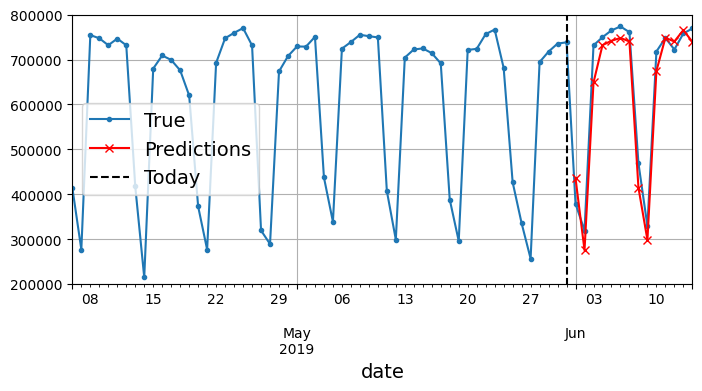

In [ ]:
Y_pred = pd.Series(X[0, -14:, 0], # coge las últimas 14 predicciones del modelo
                   index=pd.date_range("2019-06-01", "2019-06-14")) # convierte los valores en serie temporal con fechas:

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-04-06":"2019-06-14"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-05-31", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

Se visualizan las predicciones del modelo frente a los valores reales de la serie temporal. Las predicciones se obtienen a partir de las últimas secuencias generadas y se asignan a un rango de fechas correspondiente al periodo forecast.

Se representa la serie real junto con las predicciones, incluyendo una línea vertical que separa el pasado (datos conocidos) del futuro (valores predichos). Los datos se reescalan multiplicando por 1e6 para recuperar su magnitud original.

In [ ]:
y_valid  = rail_valid["2019-06-01":"2019-06-14"]

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_valid, Y_pred))*1e06)
print("MAPE:", mean_absolute_percentage_error(y_valid, Y_pred) * 100)

RMSE: 38608.26027930027
MAPE: 6.115146971231276


Hmmm, no está mal, ¿no?

**Caso 2**: Predecir seq2seq

Vamos a crear una red que entrene para predecir los 14 días siguientes de una vez.  

Para ello preparamos los datos de entrada de forma que el target serán ahora los 14 días siguientes a cada instante...   

Por tanto, si nuestras secuencias tienen 56 días, ahora el target serán 56 vectores de 14 valores (ejemplo 2 del surf, pero con 56 de tamaño de secuencia y 14 de predicción)

In [ ]:
tf.random.set_seed(42)  # fijamos la semilla para que los resultados sean reproducibles

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):  # función que separa inputs y targets
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]  
    # input  -> todas las filas del batch y todos los pasos menos los últimos 14
    # target -> los últimos 14 pasos de la secuencia, pero solo de la columna objetivo (target_col)

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),        # convertimos el dataframe multivariante a array de numpy
    targets=None,                   # no pasamos targets aquí porque los vamos a construir manualmente después
    sequence_length=seq_length + 14,# cada secuencia tendrá 56 + 14 pasos (56 para entrada y 14 para salida) - # Alargamos las secuencias
    batch_size=32,                  # agrupamos las secuencias en lotes de 32
    shuffle=True,                   # mezclamos las secuencias en entrenamiento
    seed=42,                        # semilla para el mezclado
).map(split_inputs_and_targets)     # aplicamos la función para dividir cada secuencia en X e y - # Tenemos que hacer un pequeño truco para tener los target 

ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),        # datos de validación en formato numpy
    targets=None,                   # tampoco pasamos targets, los creamos con la función map
    sequence_length=seq_length + 14,# misma longitud total de secuencia que en entrenamiento
    batch_size=32,                  # lotes de 32 secuencias
).map(split_inputs_and_targets)     # se separan inputs y targets de la misma manera 

En este paso se construye un dataset para predicción multistep, es decir, para predecir varios pasos futuros simultáneamente. Para ello, se generan secuencias de longitud total igual a seq_length + 14, donde los primeros seq_length valores se utilizan como entrada y los últimos 14 como salida esperada.

Como el objetivo es predecir únicamente una variable concreta, se utiliza una función auxiliar que separa cada secuencia en inputs multivariantes y targets correspondientes a los 14 pasos futuros de la columna objetivo. Este enfoque evita la predicción recursiva paso a paso y reduce la acumulación de errores.

In [ ]:
list(ahead_train_ds)[0]  # son 32 instancias de 56 días de 5 días 

(<tf.Tensor: shape=(32, 56, 5), dtype=float64, numpy=
 array([[[0.66921 , 0.689577, 1.      , 0.      , 0.      ],
         [0.487366, 0.452638, 0.      , 1.      , 0.      ],
         [0.382787, 0.515034, 0.      , 0.      , 1.      ],
         ...,
         [0.722447, 0.739143, 0.      , 0.      , 1.      ],
         [0.710743, 0.720004, 0.      , 0.      , 1.      ],
         [0.720279, 0.712077, 0.      , 0.      , 1.      ]],
 
        [[0.805911, 0.73984 , 1.      , 0.      , 0.      ],
         [0.439827, 0.405822, 0.      , 1.      , 0.      ],
         [0.336156, 0.295505, 0.      , 0.      , 1.      ],
         ...,
         [0.801986, 0.723334, 0.      , 0.      , 1.      ],
         [0.815252, 0.729419, 0.      , 0.      , 1.      ],
         [0.824632, 0.724399, 0.      , 0.      , 1.      ]],
 
        [[0.81511 , 0.779334, 0.      , 0.      , 1.      ],
         [0.847144, 0.784336, 0.      , 0.      , 1.      ],
         [0.838151, 0.777158, 1.      , 0.      , 0.      

In [ ]:
list(ahead_valid_ds)[0]

(<tf.Tensor: shape=(17, 56, 5), dtype=float64, numpy=
 array([[[0.487323, 0.41414 , 0.      , 1.      , 0.      ],
         [0.331229, 0.276992, 0.      , 0.      , 1.      ],
         [0.823032, 0.754465, 0.      , 0.      , 1.      ],
         ...,
         [0.791059, 0.717681, 0.      , 0.      , 1.      ],
         [0.792091, 0.735508, 0.      , 0.      , 1.      ],
         [0.817633, 0.738322, 1.      , 0.      , 0.      ]],
 
        [[0.331229, 0.276992, 0.      , 0.      , 1.      ],
         [0.823032, 0.754465, 0.      , 0.      , 1.      ],
         [0.791556, 0.747311, 0.      , 0.      , 1.      ],
         ...,
         [0.792091, 0.735508, 0.      , 0.      , 1.      ],
         [0.817633, 0.738322, 1.      , 0.      , 0.      ],
         [0.473204, 0.379044, 0.      , 1.      , 0.      ]],
 
        [[0.823032, 0.754465, 0.      , 0.      , 1.      ],
         [0.791556, 0.747311, 0.      , 0.      , 1.      ],
         [0.760548, 0.731858, 0.      , 0.      , 1.      

In [ ]:
tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [ ]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds,
                 learning_rate=0.02)

Epoch 1/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0950 - mae: 0.3187 - val_loss: 0.0174 - val_mae: 0.1431
Epoch 2/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0156 - mae: 0.1378 - val_loss: 0.0090 - val_mae: 0.1064
Epoch 3/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0120 - mae: 0.1213 - val_loss: 0.0070 - val_mae: 0.0931
Epoch 4/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0106 - mae: 0.1131 - val_loss: 0.0058 - val_mae: 0.0853
Epoch 5/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0096 - mae: 0.1061 - val_loss: 0.0048 - val_mae: 0.0771
Epoch 6/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - mae: 0.1001 - val_loss: 0.0041 - val_mae: 0.0709
Epoch 7/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0081 - mae: 0.0945 - val_loss: 0.0035 - val_mae: 0.0640
Epoch 8/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - mae: 0.0900 - val_loss: 0.0030 - val_mae: 0.0596
Epoch 9/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.00

17678.149044513702

In [ ]:
# =========================
# 📥 PREPARAR INPUT
# =========================
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  
# convertimos el dataframe a array
# np.newaxis → añadimos dimensión batch → (1, 56, 5)
# :seq_length → cogemos los primeros 56 pasos
# resultado: una única secuencia para predecir

# =========================
# 🔮 PREDICCIÓN MULTI-STEP
# =========================
Y_pred = ahead_model.predict(X)  
# el modelo predice 14 pasos futuros DE UNA VEZ
# output: (1, 14)

# =========================
# 👀 VER RESULTADO
# =========================
Y_pred
# array con 14 valores → predicciones de los próximos 14 días

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0.48238096, 0.3675689 , 0.6771686 , 0.76172334, 0.7845076 ,
        0.7716631 , 0.76177275, 0.47174314, 0.3565254 , 0.68347996,
        0.76333696, 0.7893948 , 0.74840534, 0.7710675 ]], dtype=float32)

56 días → predice directamente 14 días  - X (56 días) → Y (14 días)
[0.44, 0.32, 0.69, ..., 0.77]  predicción de rail para: día 1, día 2, ..., día 14  
Se realiza una predicción multistep directa utilizando un modelo previamente entrenado para generar múltiples pasos futuros simultáneamente. A partir de una secuencia de entrada de longitud fija (56 pasos) y múltiples variables, el modelo predice directamente los siguientes 14 valores de la variable objetivo.

Este enfoque evita la predicción recursiva paso a paso y reduce la acumulación de errores, proporcionando resultados más estables y eficientes.

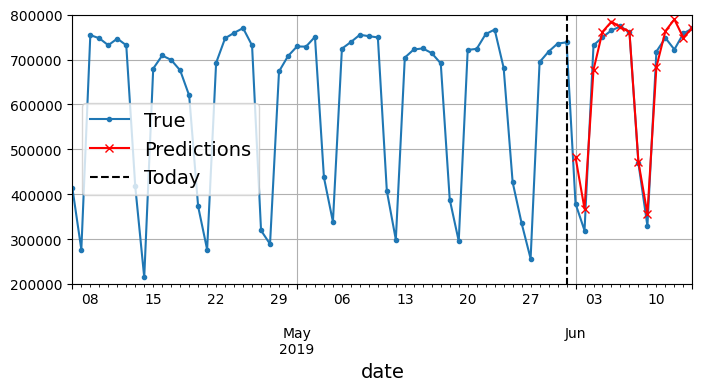

In [ ]:

Y_pred = pd.Series(Y_pred[0],
                   index=pd.date_range("2019-06-01", "2019-06-14"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-04-06":"2019-06-14"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-05-31", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_valid, Y_pred))*1e06)
print("MAPE:", mean_absolute_percentage_error(y_valid, Y_pred) * 100)

RMSE: 40745.20492738735
MAPE: 5.766211068945711


Una mejora sobre el baseline aunque no sobre la predicción sobre la predicción. La mejora puede ser debida a la predicción a 14 días entrenando con secuencias de targets o bien a que hemos empleado el modelo de series multivariante. Te dejo como ejercicio el que pruebes con el modelo univariante y predicción a 14 días.b

***

Las celdas sencillas recurrentes no son las más utilizadas hoy en día, sino que existen otros dos tipos de celdas/neuronas recurrentes que buscan mejorar ese mecanismo de hipotética memoria.   

Estas dos celdas son la LSTM (Long-short term memory) que intenta regular el impacto de periodos o elementos de la secuencia más lejanos y de los más cercanos al punto tratado. Por otro lado la celda GRU (Gated Recurrent Unit), simplifica la anterior pero también intentando regular el impacto de los diferentes elementos de la secuencia.

# LSTMs

Las celdas LSTM (Long-Short Term Memory), buscan aumentar la capacidad de "memoria". Para ello ahora además de un hidden_state, devuelven un c_state en lo que vendría a ser hidden_state -> memoria a corto plazo, c_state -> memoria a largo plazo.

Para nosotros se quedan en caja negra que funcionan mejor que las neuronas recurrentes tradicionales :-), aún así os dejo aquí el esquema de una LSTM por si a alguien le pica el gusanillo:

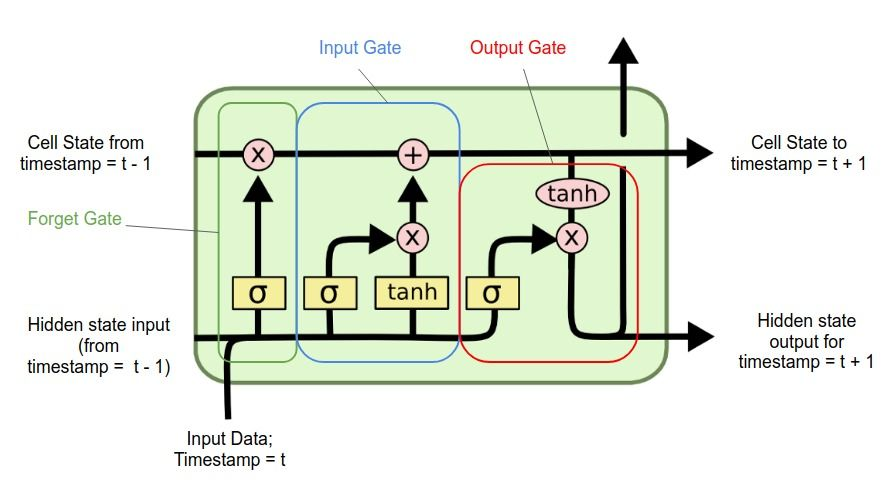


https://www.turing.com/kb/comprehensive-guide-to-lstm-rnn

Por otro lado, las celdas LSTM se pueden incorpar como tal o usando una capa especial LSTM.

| Nombre                        | Qué es                |
| ----------------------------- | --------------------- |
| Cell State (línea horizontal) | memoria a largo plazo |
| Hidden State                  | salida del paso       |
| σ (sigmoid)                   | decide cuánto pasa    |
| tanh                          | transforma valores    |

LSMT = recordar a largo plazo 🧠  
RNN: Olvida rápido  

In [ ]:
tf.random.set_seed(42)  
# fijamos semilla → reproducibilidad

lstm_model = tf.keras.models.Sequential([

    tf.keras.layers.LSTM(32, input_shape=[None, 5]),  
    # capa LSTM con 32 neuronas
    
    # input_shape:
    # None → longitud de la secuencia (ej: 56 días)
    # 5 → número de variables (multivariante)
    
    # esta capa procesa la secuencia temporal completa
    # y genera un vector resumen de tamaño 32

    tf.keras.layers.Dense(14)  
    # capa final → genera 14 valores de salida
    
    # cada uno corresponde a:
    # día 1, día 2, ..., día 14 en el futuro
])

Se define un modelo basado en LSTM para capturar dependencias temporales en una serie multivariante. La capa LSTM procesa secuencias de múltiples variables y genera una representación interna que resume la información temporal relevante.

La capa densa final produce 14 valores de salida, correspondientes a las predicciones de los siguientes 14 pasos temporales. Este enfoque permite realizar predicciones multistep directas, evitando la acumulación de errores característica de los métodos recursivos.

In [ ]:
#fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid,
 #                learning_rate=0.1, epochs=5)
fit_and_evaluate(lstm_model, ahead_train_ds, ahead_valid_ds,
                 learning_rate=0.1, epochs = 500)

Epoch 1/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032 - mae: 0.0466 - val_loss: 2.8442e-04 - val_mae: 0.0183
Epoch 2/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - mae: 0.0467 - val_loss: 2.5834e-04 - val_mae: 0.0176
Epoch 3/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - mae: 0.0473 - val_loss: 2.5751e-04 - val_mae: 0.0176
Epoch 4/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0468 - val_loss: 2.3907e-04 - val_mae: 0.0168
Epoch 5/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0465 - val_loss: 2.3196e-04 - val_mae: 0.0167
Epoch 6/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0467 - val_loss: 2.7332e-04 - val_mae: 0.0180
Epoch 7/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0466 - val_loss: 3.1026e-04 - val_mae: 0.0194
Epoch 8/500
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - mae: 0.0468 - val_loss: 2.6406e-04 - val_mae: 0.0180
Epoch 9/500
37/37 ━━━━━━━━━━━━━

16102.500259876251

In [ ]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  # shape [1, 56, 5]
Y_pred = lstm_model.predict(X)  # shape [1, 14]
Y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([[0.45697743, 0.35613227, 0.71331346, 0.76398325, 0.7752345 ,
        0.7760275 , 0.7711077 , 0.45972764, 0.34668767, 0.7115041 ,
        0.7847215 , 0.7628504 , 0.75884473, 0.7689989 ]], dtype=float32)

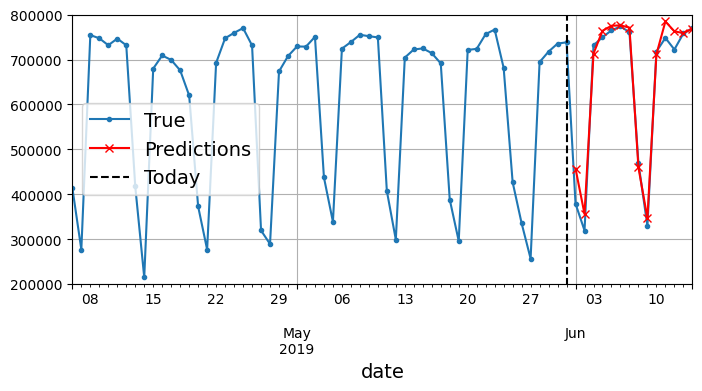

In [ ]:

Y_pred = pd.Series(Y_pred[0],
                   index=pd.date_range("2019-06-01", "2019-06-14"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-04-06":"2019-06-14"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-05-31", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_valid, Y_pred))*1e06)
print("MAPE:", mean_absolute_percentage_error(y_valid, Y_pred) * 100)

RMSE: 28771.784413484045
MAPE: 4.161061600355522


# GRUs

Las celdas GRU (Gated Recurrent Unit) son una "simplificación" de las LSTM, que intenta conseguir lo mismo, aumentar la memoria, pero simplificando algunos elementos. De hecho esta celda sólo tiene un hidden_state.

Os dejo el esquema y la referencia:

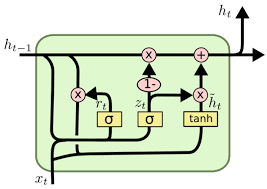

http://primo.ai/index.php?title=Gated_Recurrent_Unit_%28GRU%29

Las LSTM y las GRU son mucho más efectivas que las simples RNN y son las que se usan hoy en día. Como las LSTM, las GRU tienen su propia capa aunque puedes utilizarlas como celdas en una RNN layer (no en una SimpleRNN) y el funcionamiento es similar.


Perfecto 👌 ahora estás viendo GRU, que es como el “hermano simplificado” de LSTM 🔥- un filtro inteligente de memoria

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

In [ ]:
fit_and_evaluate(gru_model, train_ds, valid_ds, learning_rate=0.1, epochs=500)

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0329 - mae: 0.2038 - val_loss: 0.0184 - val_mae: 0.1299
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166 - mae: 0.1582 - val_loss: 0.0141 - val_mae: 0.1532
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0159 - mae: 0.1582 - val_loss: 0.0156 - val_mae: 0.1336
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0156 - mae: 0.1528 - val_loss: 0.0137 - val_mae: 0.1568
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0151 - mae: 0.1523 - val_loss: 0.0133 - val_mae: 0.1518
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154 - mae: 0.1522 - val_loss: 0.0131 - val_mae: 0.1398
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0144 - mae: 0.1482 - val_loss: 0.0125 - val_mae: 0.1478
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0149 - mae: 0.1473 - val_loss: 0.0127 - val_mae: 0.1289
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

23617.72209405899

In [ ]:

X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]

In [ ]:
for step_ahead in range(14):
    y_pred_one = gru_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


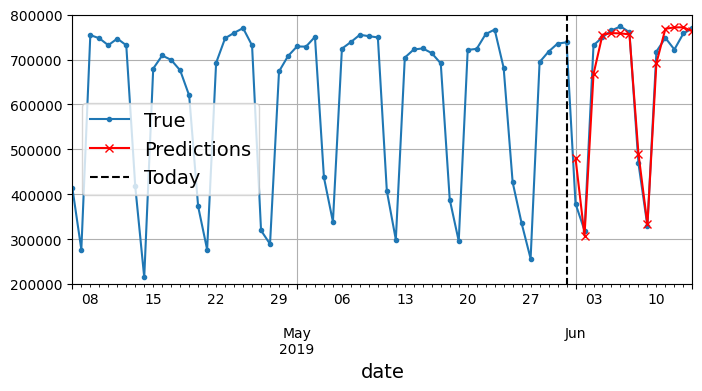

In [ ]:


Y_pred = pd.Series(X[0, -14:, 0],
                   index=pd.date_range("2019-06-01", "2019-06-14"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-04-06":"2019-06-14"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-05-31", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_valid, Y_pred))*1e06)
print("MAPE:", mean_absolute_percentage_error(y_valid, Y_pred) * 100)

RMSE: 36758.3055656174
MAPE: 4.602986644032401
